In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
sns.set_theme(style="whitegrid")
seed = 42
np.random.seed(seed)

In [3]:
caminho_arquivo = "dataset/temps_extended.xlsx"
df_completo = pd.read_excel(caminho_arquivo)

In [4]:
colunas_selecionadas = ["year", "ws_1", "temp_2", "temp_1", "average", "actual"]
df = df_completo[colunas_selecionadas].copy()

In [5]:
display(df.head())

,year,ws_1,temp_2,temp_1,average,actual
0,2011,4.92,36,37,45.6,40
1,2011,5.37,37,40,45.7,39
2,2011,6.26,40,39,45.8,42
3,2011,5.59,39,42,45.9,38
4,2011,3.80,42,38,46.0,45


In [6]:
print("\nInformações sobre valores nulos e tipos de dados:")
print(df.info())


Informações sobre valores nulos e tipos de dados:
<class 'pandas.DataFrame'>
RangeIndex: 2191 entries, 0 to 2190
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     2191 non-null   int64  
 1   ws_1     2191 non-null   float64
 2   temp_2   2191 non-null   int64  
 3   temp_1   2191 non-null   int64  
 4   average  2191 non-null   float64
 5   actual   2191 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 102.8 KB
None


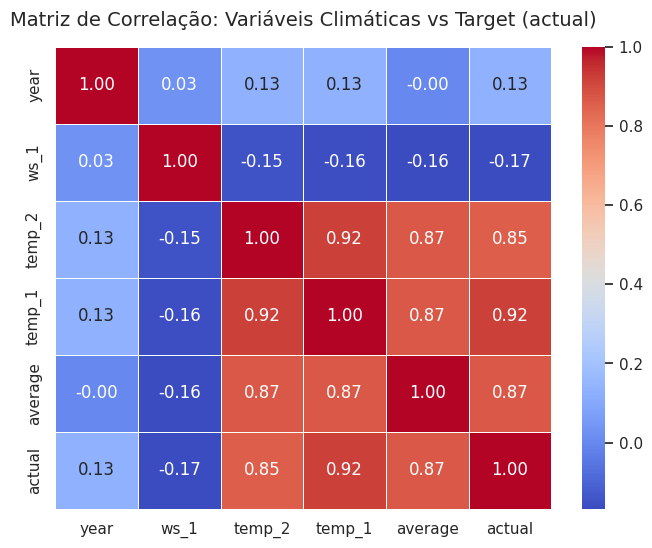

In [7]:
plt.figure(figsize=(8, 6))
matriz_correlacao = df.corr()

sns.heatmap(matriz_correlacao, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title(
    "Matriz de Correlação: Variáveis Climáticas vs Target (actual)", fontsize=14, pad=15
)
plt.show()

In [8]:
X = df.drop(columns=["actual"])
y = df["actual"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=seed
)

print(f"Total de registros originais: {len(df)}")
print(
    f"Conjunto de Treinamento: {X_train.shape[0]} amostras ({X_train.shape[0] / len(df) * 100:.0f}%)"
)
print(
    f"Conjunto de Teste: {X_test.shape[0]} amostras ({X_test.shape[0] / len(df) * 100:.0f}%)"
)

Total de registros originais: 2191
Conjunto de Treinamento: 1643 amostras (75%)
Conjunto de Teste: 548 amostras (25%)


In [9]:
def avaliar_modelo(nome_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Resultados: {nome_modelo}")
    print(f"MAE (Erro Absoluto Médio): {mae:.2f} graus")
    print(f"MSE (Erro Quadrático Médio): {mse:.2f}")
    print(f"R-quadrado (Coeficiente de Determinação): {r2:.4f}")

    return mae, mse, r2

In [10]:
rf_modelo1 = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    bootstrap=True,
    random_state=seed,
)

rf_modelo1.fit(X_train, y_train)
avaliar_modelo("Modelo 1 (Conservador)", rf_modelo1, X_test, y_test)

rf_modelo2 = RandomForestRegressor(
    n_estimators=600,
    max_depth=60,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=False,
    random_state=seed,
)

rf_modelo2.fit(X_train, y_train)
avaliar_modelo("Modelo 2 (Agressivo / Decorador)", rf_modelo2, X_test, y_test)

Resultados: Modelo 1 (Conservador)
MAE (Erro Absoluto Médio): 3.67 graus
MSE (Erro Quadrático Médio): 22.03
R-quadrado (Coeficiente de Determinação): 0.8643
Resultados: Modelo 2 (Agressivo / Decorador)
MAE (Erro Absoluto Médio): 5.17 graus
MSE (Erro Quadrático Médio): 45.29
R-quadrado (Coeficiente de Determinação): 0.7210


(5.173905109489051, 45.28854205190592, 0.7209722974001249)

In [11]:
param_grid = {
    "bootstrap": [True, False],
    "max_depth": [3, 4, 5, 10, 15, 20, 30, 40, 50, 60],
    "min_samples_leaf": [1, 2, 4],
    "min_samples_split": [2, 5, 10],
    "n_estimators": [200, 400, 600],
}

buscador = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=seed),
    param_distributions=param_grid,
    n_iter=30,
    cv=3,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    random_state=seed,
)

buscador.fit(X_train, y_train)

rf_modelo3 = buscador.best_estimator_

print("\nMelhor combinação encontrada:")
for param, valor in buscador.best_params_.items():
    print(f" - {param}: {valor}")
print("\n")

avaliar_modelo("Modelo 3 (Otimizado)", rf_modelo3, X_test, y_test)


Melhor combinação encontrada:
 - n_estimators: 600
 - min_samples_split: 2
 - min_samples_leaf: 4
 - max_depth: 10
 - bootstrap: True


Resultados: Modelo 3 (Otimizado)
MAE (Erro Absoluto Médio): 3.74 graus
MSE (Erro Quadrático Médio): 22.67
R-quadrado (Coeficiente de Determinação): 0.8603


(3.74281653858741, 22.671737365762485, 0.8603169255511456)

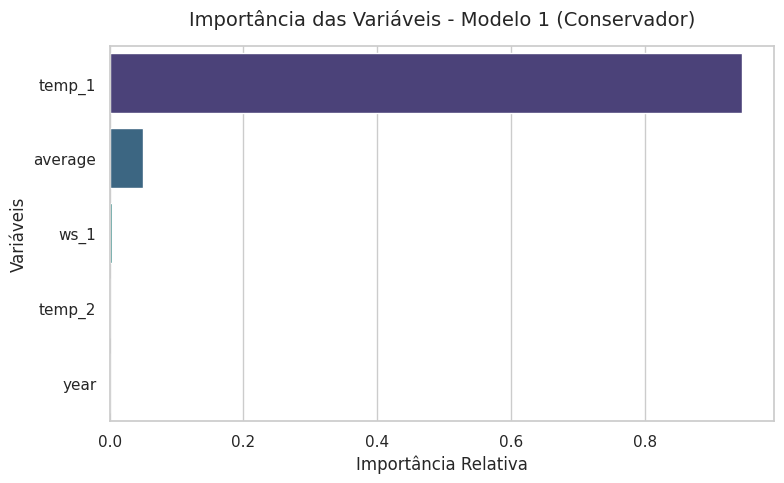

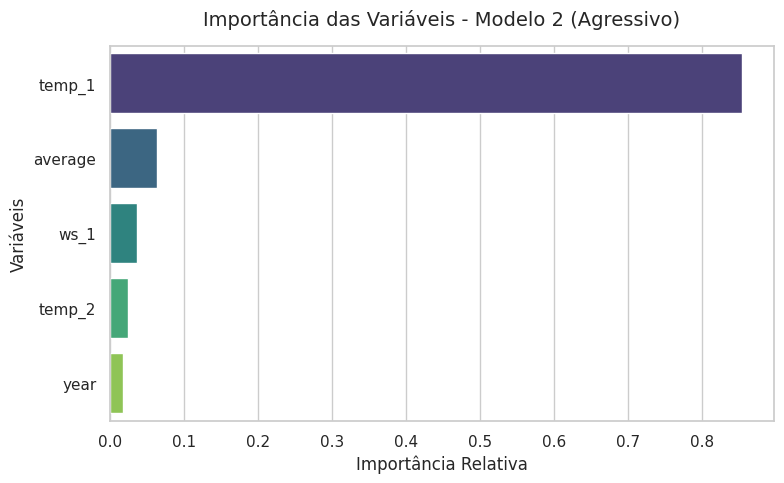

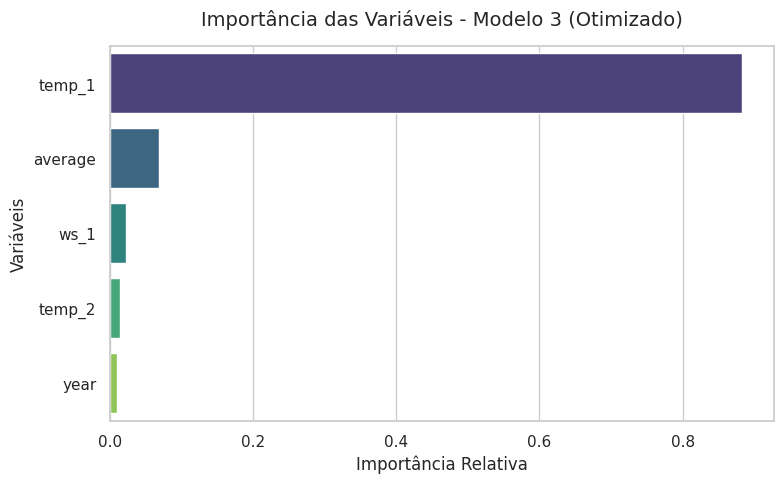

In [12]:
def plotar_importancias(modelos, nomes, colunas):
    for modelo, nome in zip(modelos, nomes):
        plt.figure(figsize=(8, 5))

        importancias = modelo.feature_importances_
        indices = np.argsort(importancias)[::-1]
        colunas_ordenadas = [colunas[i] for i in indices]
        importancias_ordenadas = importancias[indices]

        sns.barplot(
            x=importancias_ordenadas,
            y=colunas_ordenadas,
            palette="viridis",
            hue=colunas_ordenadas,
            legend=False,
        )
        plt.title(f"Importância das Variáveis - {nome}", fontsize=14, pad=15)
        plt.xlabel("Importância Relativa")
        plt.ylabel("Variáveis")

        plt.tight_layout()
        plt.show()


plotar_importancias(
    modelos=[rf_modelo1, rf_modelo2, rf_modelo3],
    nomes=["Modelo 1 (Conservador)", "Modelo 2 (Agressivo)", "Modelo 3 (Otimizado)"],
    colunas=X_train.columns,
)